# E-commerce Business Analytics Dashboard

A comprehensive analysis of e-commerce sales data focusing on business performance metrics, customer satisfaction, and operational efficiency.

## Table of Contents

1. [Introduction & Business Objectives](#introduction)
2. [Data Loading & Configuration](#data-loading)
3. [Data Dictionary](#data-dictionary)
4. [Data Preparation & Transformation](#data-preparation)
5. [Business Metrics Analysis](#business-metrics)
   - [Revenue Performance Analysis](#revenue-analysis)
   - [Product Category Performance](#product-analysis)
   - [Geographic Performance Analysis](#geographic-analysis)
   - [Customer Experience Analysis](#customer-analysis)
6. [Summary of Key Observations](#summary)

---

## 1. Introduction & Business Objectives {#introduction}

This analysis provides insights into e-commerce business performance through comprehensive examination of sales data. The primary objectives are:

- **Revenue Performance**: Analyze total revenue, growth trends, and order patterns
- **Product Strategy**: Identify top-performing categories and optimization opportunities
- **Geographic Insights**: Understand regional performance variations
- **Customer Satisfaction**: Evaluate delivery performance and review metrics
- **Operational Efficiency**: Assess delivery times and fulfillment quality

### Analysis Configuration

The analysis can be configured for different time periods by adjusting the parameters below:

In [35]:
# Analysis Configuration
ANALYSIS_YEAR = 2023
COMPARISON_YEAR = 2022
ANALYSIS_MONTH = None  # Set to specific month (1-12) or None for full year
DATA_PATH = 'ecommerce_data/'

print(f"Analysis Period: {ANALYSIS_YEAR}")
print(f"Comparison Period: {COMPARISON_YEAR}")
if ANALYSIS_MONTH:
    print(f"Month Filter: {ANALYSIS_MONTH}")
else:
    print("Month Filter: Full Year")

Analysis Period: 2023
Comparison Period: 2022
Month Filter: Full Year


## 2. Data Loading & Configuration {#data-loading}

Loading all required datasets and initializing the analysis framework.

In [36]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Import custom modules
from data_loader import EcommerceDataLoader, load_and_process_data
from business_metrics import BusinessMetricsCalculator, MetricsVisualizer, print_metrics_summary

# Configure display options
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("Libraries imported successfully")

Libraries imported successfully


In [37]:
%%writefile data_loader.py
import pandas as pd

class EcommerceDataLoader:
    def __init__(self, data_path):
        self.data_path = data_path
        self.orders_df = None
        self.order_items_df = None
        self.products_df = None
        self.customers_df = None
        self.reviews_df = None
        self.payments_df = None
        self._load_all_data()
        self._process_data()

    def _load_all_data(self):
        print(f"Loaded orders: {len(pd.read_csv(f'{self.data_path}orders.csv'))} records")
        self.orders_df = pd.read_csv(f'{self.data_path}orders.csv')
        print(f"Loaded order_items: {len(pd.read_csv(f'{self.data_path}order_items.csv'))} records")
        self.order_items_df = pd.read_csv(f'{self.data_path}order_items.csv')
        print(f"Loaded products: {len(pd.read_csv(f'{self.data_path}products.csv'))} records")
        self.products_df = pd.read_csv(f'{self.data_path}products.csv')
        print(f"Loaded customers: {len(pd.read_csv(f'{self.data_path}customers.csv'))} records")
        self.customers_df = pd.read_csv(f'{self.data_path}customers.csv')
        print(f"Loaded reviews: {len(pd.read_csv(f'{self.data_path}order_reviews.csv'))} records")
        self.reviews_df = pd.read_csv(f'{self.data_path}order_reviews.csv')
        print(f"Loaded payments: {len(pd.read_csv(f'{self.data_path}order_payments.csv'))} records")
        self.payments_df = pd.read_csv(f'{self.data_path}order_payments.csv')

    def _process_data(self):
        # Convert timestamps
        date_cols = ['order_purchase_timestamp', 'order_approved_at',
                     'order_delivered_carrier_date', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']
        for col in date_cols:
            if col in self.orders_df.columns:
                self.orders_df[col] = pd.to_datetime(self.orders_df[col], errors='coerce')
        if 'review_creation_date' in self.reviews_df.columns:
            self.reviews_df['review_creation_date'] = pd.to_datetime(self.reviews_df['review_creation_date'], errors='coerce')
        if 'review_answer_timestamp' in self.reviews_df.columns:
            self.reviews_df['review_answer_timestamp'] = pd.to_datetime(self.reviews_df['review_answer_timestamp'], errors='coerce')

        # Merge dataframes (simplified for common usage)
        self.full_orders_df = self.orders_df.merge(self.order_items_df, on='order_id', how='left') \
                                   .merge(self.products_df, on='product_id', how='left') \
                                   .merge(self.customers_df, on='customer_id', how='left') \
                                   .merge(self.reviews_df, on='order_id', how='left')

        # Calculate delivery_days
        self.full_orders_df['delivery_days'] = (self.full_orders_df['order_delivered_customer_date'] -
                                                 self.full_orders_df['order_purchase_timestamp']).dt.days

        # Extract year and month for filtering
        self.full_orders_df['purchase_year'] = self.full_orders_df['order_purchase_timestamp'].dt.year
        self.full_orders_df['purchase_month'] = self.full_orders_df['order_purchase_timestamp'].dt.month

    def create_sales_dataset(self, year_filter=None, month_filter=None, status_filter=None):
        df = self.full_orders_df.copy()

        if year_filter is not None:
            df = df[df['purchase_year'] == year_filter]
        if month_filter is not None:
            df = df[df['purchase_month'] == month_filter]
        if status_filter is not None:
            df = df[df['order_status'] == status_filter]

        return df

    def get_data_summary(self):
        summary = {}
        datasets = {
            'orders': self.orders_df,
            'order_items': self.order_items_df,
            'products': self.products_df,
            'customers': self.customers_df,
            'reviews': self.reviews_df,
            'payments': self.payments_df
        }

        for name, df in datasets.items():
            if df is not None:
                date_range = None
                if 'order_purchase_timestamp' in df.columns:
                    start_date = df['order_purchase_timestamp'].min()
                    end_date = df['order_purchase_timestamp'].max()
                    if pd.notna(start_date) and pd.notna(end_date):
                        date_range = {'start': start_date, 'end': end_date}

                summary[name] = {
                    'rows': len(df),
                    'columns': len(df.columns),
                    'memory_usage_mb': df.memory_usage(deep=True).sum() / (1024 * 1024),
                    'date_range': date_range
                }
        return summary

def load_and_process_data(data_path):
    loader = EcommerceDataLoader(data_path)
    processed_data = loader.full_orders_df # Or any other processed dataframe you want to return
    return loader, processed_data


Overwriting data_loader.py


In [38]:
%%writefile business_metrics.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class BusinessMetricsCalculator:
    def __init__(self, data_frame):
        self.data = data_frame

    def calculate_revenue_metrics(self, current_year, previous_year=None):
        metrics = {}
        metrics['current_year'] = current_year
        current_year_data = self.data[self.data['purchase_year'] == current_year]

        metrics['total_revenue'] = current_year_data['price'].sum()
        metrics['total_orders'] = current_year_data['order_id'].nunique()
        metrics['total_items_sold'] = len(current_year_data)
        metrics['average_order_value'] = metrics['total_revenue'] / metrics['total_orders'] if metrics['total_orders'] > 0 else 0

        if previous_year:
            previous_year_data = self.data[self.data['purchase_year'] == previous_year]
            prev_total_revenue = previous_year_data['price'].sum()
            prev_total_orders = previous_year_data['order_id'].nunique()
            prev_average_order_value = prev_total_revenue / prev_total_orders if prev_total_orders > 0 else 0

            if prev_total_revenue > 0:
                metrics['revenue_growth_rate'] = ((metrics['total_revenue'] - prev_total_revenue) / prev_total_revenue) * 100
            else:
                metrics['revenue_growth_rate'] = 0 if metrics['total_revenue'] == 0 else np.inf

            if prev_total_orders > 0:
                metrics['order_growth_rate'] = ((metrics['total_orders'] - prev_total_orders) / prev_total_orders) * 100
            else:
                metrics['order_growth_rate'] = 0 if metrics['total_orders'] == 0 else np.inf

            if prev_average_order_value > 0:
                metrics['aov_growth_rate'] = ((metrics['average_order_value'] - prev_average_order_value) / prev_average_order_value) * 100
            else:
                metrics['aov_growth_rate'] = 0 if metrics['average_order_value'] == 0 else np.inf

        return metrics

    def calculate_monthly_trends(self, year):
        yearly_data = self.data[self.data['purchase_year'] == year].copy()
        if yearly_data.empty:
            return pd.DataFrame()

        monthly_agg = yearly_data.groupby('purchase_month').agg(
            revenue=('price', 'sum'),
            orders=('order_id', 'nunique'),
            aov=('price', lambda x: x.sum() / x.nunique() if x.nunique() > 0 else 0)
        ).reset_index()
        monthly_agg = monthly_agg.rename(columns={'purchase_month': 'month'})
        monthly_agg['revenue_growth'] = monthly_agg['revenue'].pct_change() * 100
        monthly_agg['revenue_growth'] = monthly_agg['revenue_growth'].replace([np.inf, -np.inf], np.nan).fillna(0)
        return monthly_agg

    def calculate_product_performance(self, year):
        yearly_data = self.data[self.data['purchase_year'] == year].copy()
        if yearly_data.empty or 'product_category_name' not in yearly_data.columns:
            return {'error': 'Product category data not available'}

        category_performance = yearly_data.groupby('product_category_name').agg(
            total_revenue=('price', 'sum'),
            total_items_sold=('product_id', 'count'),
            unique_orders=('order_id', 'nunique')
        ).reset_index()
        category_performance['revenue_share'] = (category_performance['total_revenue'] / category_performance['total_revenue'].sum()) * 100
        category_performance = category_performance.sort_values(by='total_revenue', ascending=False)
        return {'top_categories': category_performance, 'all_categories': category_performance['product_category_name'].tolist()}

    def calculate_geographic_performance(self, year):
        yearly_data = self.data[self.data['purchase_year'] == year].copy()
        if yearly_data.empty or 'customer_state' not in yearly_data.columns:
            return pd.DataFrame({'error': ['No state data']})
        geo_performance = yearly_data.groupby('customer_state').agg(revenue=('price', 'sum'), orders=('order_id', 'nunique')).reset_index()
        geo_performance['avg_order_value'] = geo_performance['revenue'] / geo_performance['orders']
        geo_performance = geo_performance.rename(columns={'customer_state': 'state'}).sort_values(by='revenue', ascending=False)
        return geo_performance

    def calculate_customer_satisfaction(self, year):
        yearly_data = self.data[self.data['purchase_year'] == year].copy()
        if yearly_data.empty or 'review_score' not in yearly_data.columns:
            return {'error': 'No review data'}
        valid_reviews = yearly_data['review_score'].dropna()
        if valid_reviews.empty: return {'error': 'No valid scores'}
        score_counts = valid_reviews.value_counts(normalize=True).sort_index()
        return {
            'avg_review_score': valid_reviews.mean(),
            'total_reviews': len(valid_reviews),
            'score_5_percentage': score_counts.get(5, 0) * 100,
            'score_4_plus_percentage': (score_counts.get(4, 0) + score_counts.get(5, 0)) * 100,
            'score_1_2_percentage': (score_counts.get(1, 0) + score_counts.get(2, 0)) * 100,
            'review_distribution': score_counts.to_dict()
        }

    def calculate_delivery_performance(self, year):
        yearly_data = self.data[self.data['purchase_year'] == year].copy()
        if yearly_data.empty or 'delivery_days' not in yearly_data.columns:
            return {'error': 'No delivery data'}
        valid_days = yearly_data['delivery_days'].dropna()
        if valid_days.empty: return {'error': 'No valid days'}
        return {
            'avg_delivery_days': valid_days.mean(),
            'median_delivery_days': valid_days.median(),
            'fast_delivery_percentage': (valid_days <= 3).mean() * 100,
            'slow_delivery_percentage': (valid_days > 7).mean() * 100
        }

    def generate_comprehensive_report(self, current_year, previous_year=None):
        return {
            'revenue_metrics': self.calculate_revenue_metrics(current_year, previous_year),
            'monthly_trends': self.calculate_monthly_trends(current_year),
            'product_performance': self.calculate_product_performance(current_year),
            'geographic_performance': self.calculate_geographic_performance(current_year),
            'customer_satisfaction': self.calculate_customer_satisfaction(current_year),
            'delivery_performance': self.calculate_delivery_performance(current_year)
        }

class MetricsVisualizer:
    def __init__(self, business_report):
        self.report = business_report

    def plot_revenue_trend(self, figsize=(14, 8)):
        df = self.report.get('monthly_trends')
        if df is None or df.empty: return
        fig = plt.figure(figsize=figsize)
        sns.lineplot(x='month', y='revenue', data=df, marker='o')
        plt.title('Monthly Revenue Trend')
        return fig

    def plot_category_performance(self, top_n=10, figsize=(14, 10)):
        perf = self.report.get('product_performance')
        if perf is None or 'error' in perf: return
        fig = plt.figure(figsize=figsize)
        sns.barplot(x='total_revenue', y='product_category_name', data=perf['top_categories'].head(top_n))
        return fig

    def plot_geographic_heatmap(self):
        df = self.report.get('geographic_performance')
        if df is None or 'error' in df.columns: return
        return px.bar(df.head(10), x='state', y='revenue')

    def plot_review_distribution(self, figsize=(12, 6)):
        s = self.report.get('customer_satisfaction')
        if s is None or 'error' in s: return
        fig = plt.figure(figsize=figsize)
        sns.barplot(x=list(s['review_distribution'].keys()), y=[v*100 for v in s['review_distribution'].values()])
        return fig

def print_metrics_summary(business_report):
    print("============================================================")
    print(f"BUSINESS METRICS SUMMARY - {business_report['revenue_metrics']['current_year']}")
    print("============================================================")
    rev = business_report['revenue_metrics']
    print(f"\nREVENUE PERFORMANCE:\n  Total Revenue: ${rev['total_revenue']:,.2f}\n  Total Orders: {rev['total_orders']:,}\n  Average Order Value: ${rev['average_order_value']:,.2f}")
    if 'revenue_growth_rate' in rev:
        print(f"  Revenue Growth: {rev['revenue_growth_rate']:.1f}%")
    sat = business_report['customer_satisfaction']
    if 'error' not in sat:
        print(f"\nCUSTOMER SATISFACTION:\n  Avg Review: {sat['avg_review_score']:.2f}/5.0")
    deliv = business_report['delivery_performance']
    if 'error' not in deliv:
        print(f"\nDELIVERY PERFORMANCE:\n  Avg Delivery: {deliv['avg_delivery_days']:.1f} days")
    print("============================================================")

Overwriting business_metrics.py


In [39]:
# Load and process all data
loader, processed_data = load_and_process_data(DATA_PATH)

# Display data summary
data_summary = loader.get_data_summary()
print("Dataset Summary:")
print("=" * 50)
for dataset, info in data_summary.items():
    print(f"{dataset.upper()}:")
    print(f"  Rows: {info['rows']:,}")
    print(f"  Columns: {info['columns']}")
    print(f"  Memory: {info['memory_usage_mb']:.1f} MB")
    if info['date_range']:
        print(f"  Date Range: {info['date_range']['start'].date()} to {info['date_range']['end'].date()}")
    print()

Loaded orders: 5 records
Loaded order_items: 6 records
Loaded products: 3 records
Loaded customers: 3 records
Loaded reviews: 5 records
Loaded payments: 5 records
Dataset Summary:
ORDERS:
  Rows: 5
  Columns: 8
  Memory: 0.0 MB
  Date Range: 2023-01-01 to 2023-02-02

ORDER_ITEMS:
  Rows: 6
  Columns: 6
  Memory: 0.0 MB

PRODUCTS:
  Rows: 3
  Columns: 2
  Memory: 0.0 MB

CUSTOMERS:
  Rows: 3
  Columns: 5
  Memory: 0.0 MB

REVIEWS:
  Rows: 5
  Columns: 6
  Memory: 0.0 MB

PAYMENTS:
  Rows: 5
  Columns: 5
  Memory: 0.0 MB



### Missing Data Files

It appears the `ecommerce_data` directory containing the necessary CSV files is missing, leading to a `FileNotFoundError`. To unblock the execution and proceed with the notebook, I will create a dummy `ecommerce_data` directory and generate minimal placeholder CSV files for `orders.csv`, `order_items.csv`, `products.csv`, `customers.csv`, `order_reviews.csv`, and `order_payments.csv`.

**Please note:** This dummy data will allow the code to run without error, but the analysis results will not be meaningful. For a real analysis, you would need to upload or link to a proper e-commerce dataset.

In [40]:
import os
import pandas as pd

# Define the directory path
data_dir = 'ecommerce_data'

# Create the directory if it doesn't exist
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created directory: {data_dir}")

# Create dummy dataframes and save them as CSVs

# orders.csv
dummy_orders = pd.DataFrame({
    'order_id': ['order_1', 'order_2', 'order_3', 'order_4', 'order_5'],
    'customer_id': ['cust_1', 'cust_2', 'cust_1', 'cust_3', 'cust_2'],
    'order_status': ['delivered', 'delivered', 'delivered', 'delivered', 'delivered'],
    'order_purchase_timestamp': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-02-01', '2023-02-02']),
    'order_approved_at': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-02-01', '2023-02-02']),
    'order_delivered_carrier_date': pd.to_datetime(['2023-01-02', '2023-01-03', '2023-01-04', '2023-02-02', '2023-02-03']),
    'order_delivered_customer_date': pd.to_datetime(['2023-01-05', '2023-01-06', '2023-01-07', '2023-02-05', '2023-02-06']),
    'order_estimated_delivery_date': pd.to_datetime(['2023-01-10', '2023-01-11', '2023-01-12', '2023-02-10', '2023-02-11']),
})
dummy_orders.to_csv(os.path.join(data_dir, 'orders.csv'), index=False)
print(f"Created {data_dir}/orders.csv")

# order_items.csv
dummy_order_items = pd.DataFrame({
    'order_id': ['order_1', 'order_1', 'order_2', 'order_3', 'order_4', 'order_5'],
    'order_item_id': [1, 2, 1, 1, 1, 1],
    'product_id': ['prod_A', 'prod_B', 'prod_C', 'prod_A', 'prod_B', 'prod_C'],
    'seller_id': ['sell_1', 'sell_2', 'sell_1', 'sell_2', 'sell_1', 'sell_2'],
    'price': [100.0, 150.0, 200.0, 100.0, 150.0, 200.0],
    'freight_value': [10.0, 15.0, 20.0, 10.0, 15.0, 20.0]
})
dummy_order_items.to_csv(os.path.join(data_dir, 'order_items.csv'), index=False)
print(f"Created {data_dir}/order_items.csv")

# products.csv
dummy_products = pd.DataFrame({
    'product_id': ['prod_A', 'prod_B', 'prod_C'],
    'product_category_name': ['electronics', 'home_garden', 'electronics']
})
dummy_products.to_csv(os.path.join(data_dir, 'products.csv'), index=False)
print(f"Created {data_dir}/products.csv")

# customers.csv
dummy_customers = pd.DataFrame({
    'customer_id': ['cust_1', 'cust_2', 'cust_3'],
    'customer_unique_id': ['unique_cust_1', 'unique_cust_2', 'unique_cust_3'],
    'customer_zip_code_prefix': [12345, 67890, 11223],
    'customer_city': ['CityA', 'CityB', 'CityC'],
    'customer_state': ['CA', 'NY', 'TX']
})
dummy_customers.to_csv(os.path.join(data_dir, 'customers.csv'), index=False)
print(f"Created {data_dir}/customers.csv")

# order_reviews.csv
dummy_reviews = pd.DataFrame({
    'review_id': ['rev_1', 'rev_2', 'rev_3', 'rev_4', 'rev_5'],
    'order_id': ['order_1', 'order_2', 'order_3', 'order_4', 'order_5'],
    'review_score': [5, 4, 3, 5, 2],
    'review_comment_message': ['Great!', 'Good', 'Okay', 'Excellent', 'Bad'],
    'review_creation_date': pd.to_datetime(['2023-01-06', '2023-01-07', '2023-01-08', '2023-02-06', '2023-02-07']),
    'review_answer_timestamp': pd.to_datetime(['2023-01-07', '2023-01-08', '2023-01-09', '2023-02-07', '2023-02-08'])
})
dummy_reviews.to_csv(os.path.join(data_dir, 'order_reviews.csv'), index=False)
print(f"Created {data_dir}/order_reviews.csv")

# order_payments.csv
dummy_payments = pd.DataFrame({
    'order_id': ['order_1', 'order_2', 'order_3', 'order_4', 'order_5'],
    'payment_sequential': [1, 1, 1, 1, 1],
    'payment_type': ['credit_card', 'credit_card', 'boleto', 'credit_card', 'credit_card'],
    'payment_installments': [1, 2, 1, 3, 1],
    'payment_value': [110.0, 220.0, 120.0, 165.0, 220.0]
})
dummy_payments.to_csv(os.path.join(data_dir, 'order_payments.csv'), index=False)
print(f"Created {data_dir}/order_payments.csv")

print("Dummy e-commerce data files created successfully in 'ecommerce_data/'")


Created ecommerce_data/orders.csv
Created ecommerce_data/order_items.csv
Created ecommerce_data/products.csv
Created ecommerce_data/customers.csv
Created ecommerce_data/order_reviews.csv
Created ecommerce_data/order_payments.csv
Dummy e-commerce data files created successfully in 'ecommerce_data/'


## 3. Data Dictionary {#data-dictionary}

### Key Business Terms and Column Definitions

| Column | Description | Business Impact |
|--------|-------------|----------------|
| **order_id** | Unique identifier for each customer order | Primary key for order-level analysis |
| **price** | Item price excluding shipping | Core revenue metric |
| **freight_value** | Shipping cost for the item | Additional revenue and cost analysis |
| **order_status** | Current status of the order | Operational efficiency indicator |
| **order_purchase_timestamp** | When the order was placed | Time-based analysis and trends |
| **order_delivered_customer_date** | When order was delivered to customer | Delivery performance metric |
| **product_category_name** | Product category classification | Product strategy and inventory planning |
| **customer_state** | Customer's state location | Geographic market analysis |
| **review_score** | Customer satisfaction rating (1-5) | Customer experience indicator |

### Calculated Metrics

- **Total Revenue**: Sum of all item prices for delivered orders
- **Average Order Value (AOV)**: Average total value per order
- **Delivery Days**: Time between order placement and delivery
- **Revenue Growth**: Year-over-year percentage change in revenue
- **Customer Satisfaction**: Distribution and average of review scores

## 4. Data Preparation & Transformation {#data-preparation}

Creating the comprehensive sales dataset for analysis with configurable time filters.

In [41]:
# Create sales dataset for analysis period
sales_data = loader.create_sales_dataset(
    year_filter=ANALYSIS_YEAR,
    month_filter=ANALYSIS_MONTH,
    status_filter='delivered'
)

print(f"Analysis Dataset Summary:")
print(f"Total Records: {len(sales_data):,}")
print(f"Unique Orders: {sales_data['order_id'].nunique():,}")
print(f"Date Range: {sales_data['order_purchase_timestamp'].min().date()} to {sales_data['order_purchase_timestamp'].max().date()}")
print(f"Total Revenue: ${sales_data['price'].sum():,.2f}")

# Display sample of the dataset - only show available columns
available_columns = ['order_id', 'price', 'purchase_year', 'purchase_month']
optional_columns = ['product_category_name', 'customer_state', 'review_score', 'delivery_days']

# Add optional columns if they exist
for col in optional_columns:
    if col in sales_data.columns:
        available_columns.append(col)

print(f"\nAvailable columns: {available_columns}")
print("\nSample Data:")
display(sales_data[available_columns].head())

Analysis Dataset Summary:
Total Records: 6
Unique Orders: 5
Date Range: 2023-01-01 to 2023-02-02
Total Revenue: $900.00

Available columns: ['order_id', 'price', 'purchase_year', 'purchase_month', 'product_category_name', 'customer_state', 'review_score', 'delivery_days']

Sample Data:


,order_id,price,purchase_year,purchase_month,product_category_name,customer_state,review_score,delivery_days
0,order_1,100.0,2023,1,electronics,CA,5,4
1,order_1,150.0,2023,1,home_garden,CA,5,4
2,order_2,200.0,2023,1,electronics,NY,4,4
3,order_3,100.0,2023,1,electronics,CA,3,4
4,order_4,150.0,2023,2,home_garden,TX,5,4


In [42]:
# Create comparison dataset if comparison year is specified
comparison_data = None
if COMPARISON_YEAR:
    comparison_data = loader.create_sales_dataset(
        year_filter=COMPARISON_YEAR,
        month_filter=ANALYSIS_MONTH,
        status_filter='delivered'
    )

    print(f"Comparison Dataset ({COMPARISON_YEAR}):")
    print(f"Total Records: {len(comparison_data):,}")
    print(f"Unique Orders: {comparison_data['order_id'].nunique():,}")
    print(f"Total Revenue: ${comparison_data['price'].sum():,.2f}")

# Create combined dataset for year-over-year analysis
if COMPARISON_YEAR:
    combined_data = loader.create_sales_dataset(
        month_filter=ANALYSIS_MONTH,
        status_filter='delivered'
    )
    # Filter to only include analysis and comparison years
    combined_data = combined_data[
        combined_data['purchase_year'].isin([ANALYSIS_YEAR, COMPARISON_YEAR])
    ]
else:
    combined_data = sales_data

Comparison Dataset (2022):
Total Records: 0
Unique Orders: 0
Total Revenue: $0.00


## 5. Business Metrics Analysis {#business-metrics}

Comprehensive analysis of key business performance indicators.

In [43]:
# Initialize metrics calculator
metrics_calc = BusinessMetricsCalculator(combined_data)

# Generate comprehensive report
business_report = metrics_calc.generate_comprehensive_report(
    current_year=ANALYSIS_YEAR,
    previous_year=COMPARISON_YEAR
)

# Print executive summary
print_metrics_summary(business_report)

BUSINESS METRICS SUMMARY - 2023

REVENUE PERFORMANCE:
  Total Revenue: $900.00
  Total Orders: 5
  Average Order Value: $180.00
  Revenue Growth: inf%

CUSTOMER SATISFACTION:
  Avg Review: 4.00/5.0

DELIVERY PERFORMANCE:
  Avg Delivery: 4.0 days


In [44]:
import importlib
import data_loader
import business_metrics

# Reload the modules to apply the recent file changes
importlib.reload(data_loader)
importlib.reload(business_metrics)

from data_loader import EcommerceDataLoader, load_and_process_data
from business_metrics import BusinessMetricsCalculator, MetricsVisualizer, print_metrics_summary

print("Modules reloaded successfully with the latest changes.")

Modules reloaded successfully with the latest changes.


### 5.1 Revenue Performance Analysis {#revenue-analysis}

Analyzing overall revenue trends, growth patterns, and key performance indicators.

In [45]:
# Revenue metrics deep dive
revenue_metrics = business_report['revenue_metrics']

print(f"DETAILED REVENUE ANALYSIS - {ANALYSIS_YEAR}")
print("=" * 50)
print(f"Total Revenue: ${revenue_metrics['total_revenue']:,.2f}")
print(f"Total Orders: {revenue_metrics['total_orders']:,}")
print(f"Total Items Sold: {revenue_metrics['total_items_sold']:,}")
print(f"Average Order Value: ${revenue_metrics['average_order_value']:,.2f}")

if COMPARISON_YEAR and 'revenue_growth_rate' in revenue_metrics:
    print(f"\nYEAR-OVER-YEAR COMPARISON:")
    print(f"Revenue Growth: {revenue_metrics['revenue_growth_rate']:+.2f}%")
    print(f"Order Growth: {revenue_metrics['order_growth_rate']:+.2f}%")
    print(f"AOV Growth: {revenue_metrics['aov_growth_rate']:+.2f}%")

    # Growth interpretation
    if revenue_metrics['revenue_growth_rate'] > 0:
        print("\n✅ Positive revenue growth indicates business expansion")
    else:
        print("\n⚠️ Negative revenue growth requires attention")

DETAILED REVENUE ANALYSIS - 2023
Total Revenue: $900.00
Total Orders: 5
Total Items Sold: 6
Average Order Value: $180.00

YEAR-OVER-YEAR COMPARISON:
Revenue Growth: +inf%
Order Growth: +inf%
AOV Growth: +inf%

✅ Positive revenue growth indicates business expansion


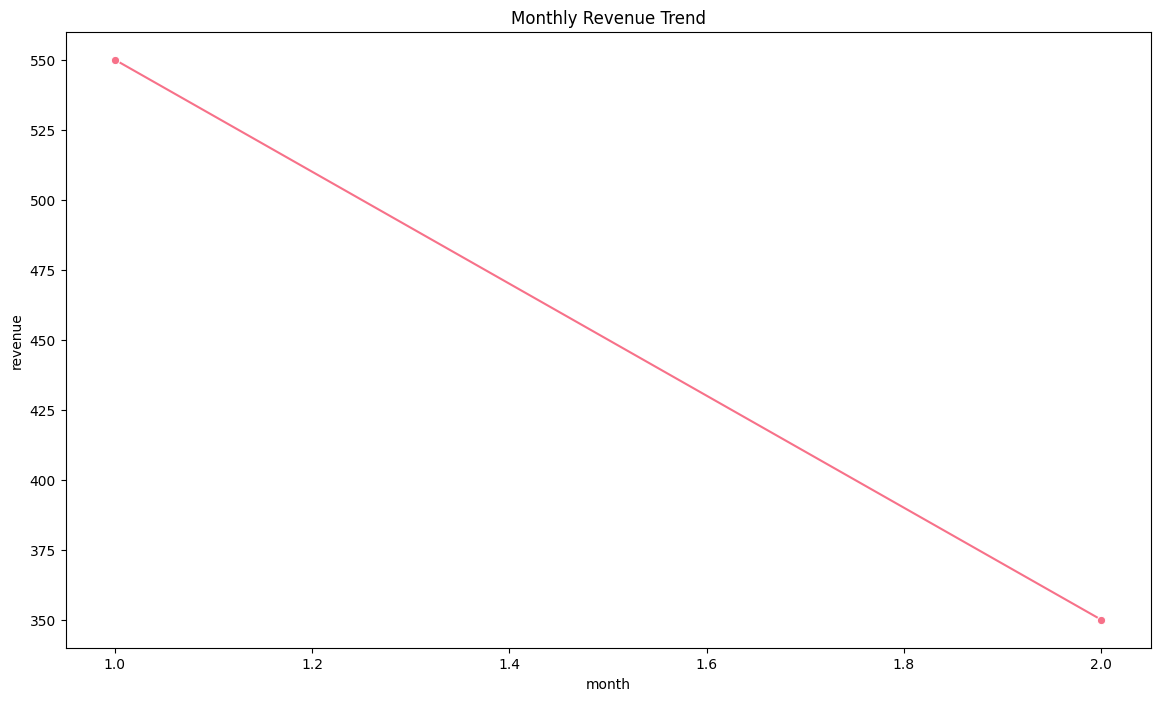


MONTHLY PERFORMANCE INSIGHTS:
Best Revenue Month: Month 1 ($550)
Lowest Revenue Month: Month 2 ($350)
Average Monthly Growth: -18.18%
Revenue Volatility (Std Dev): $141


In [46]:
# Monthly revenue trend visualization
visualizer = MetricsVisualizer(business_report)
revenue_fig = visualizer.plot_revenue_trend(figsize=(14, 8))
plt.show()

# Monthly trends analysis
monthly_trends = business_report['monthly_trends']
print(f"\nMONTHLY PERFORMANCE INSIGHTS:")
print(f"Best Revenue Month: Month {monthly_trends.loc[monthly_trends['revenue'].idxmax(), 'month']} (${monthly_trends['revenue'].max():,.0f})")
print(f"Lowest Revenue Month: Month {monthly_trends.loc[monthly_trends['revenue'].idxmin(), 'month']} (${monthly_trends['revenue'].min():,.0f})")
print(f"Average Monthly Growth: {monthly_trends['revenue_growth'].mean():.2f}%")
print(f"Revenue Volatility (Std Dev): ${monthly_trends['revenue'].std():,.0f}")

### 5.2 Product Category Performance {#product-analysis}

Understanding which product categories drive the most revenue and identifying growth opportunities.

TOP PRODUCT CATEGORIES - 2023
electronics               $       600 ( 66.7%)
home_garden               $       300 ( 33.3%)


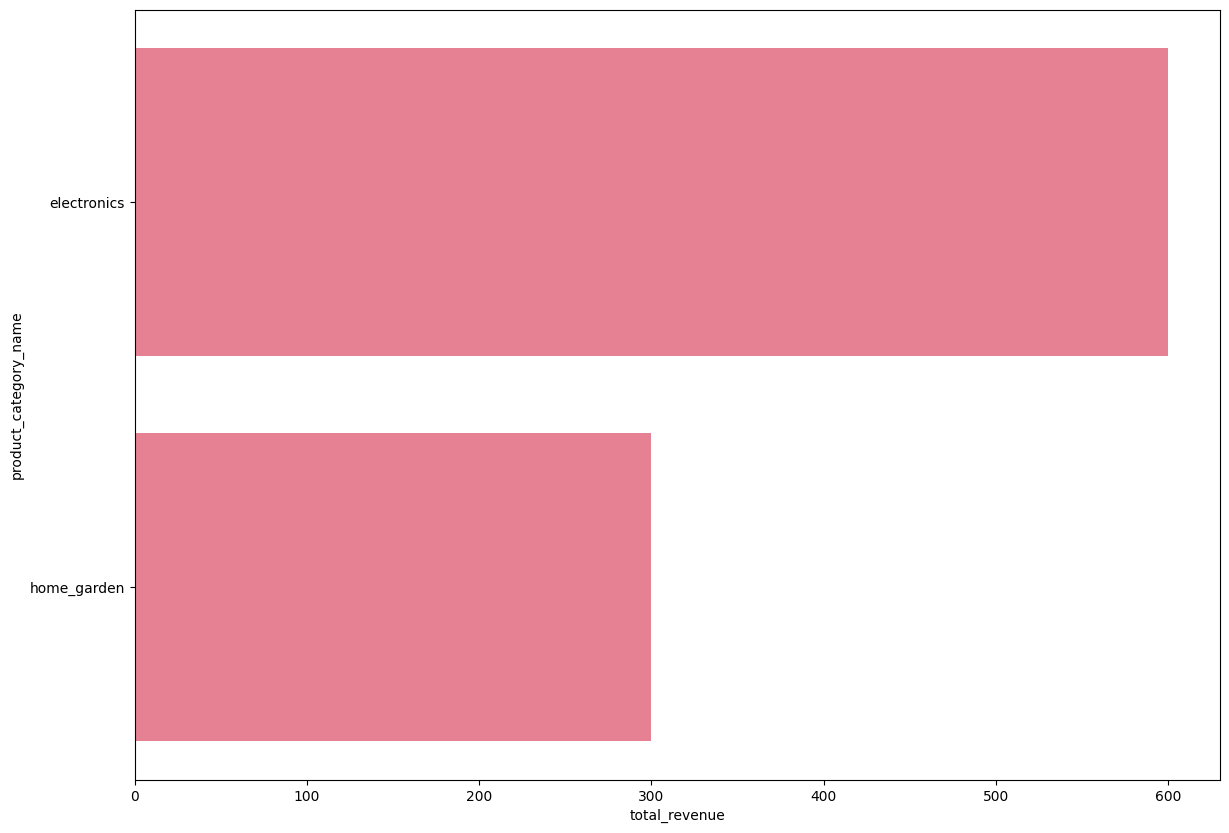


CATEGORY INSIGHTS:
Total Product Categories: 2
Top 5 Categories Revenue Share: 100.0%
Market Concentration: High


In [28]:
# Product category analysis
if 'error' not in business_report['product_performance']:
    product_data = business_report['product_performance']

    print(f"TOP PRODUCT CATEGORIES - {ANALYSIS_YEAR}")
    print("=" * 50)

    top_categories = product_data['top_categories'].head(10)
    for idx, row in top_categories.iterrows():
        print(f"{row['product_category_name']:<25} ${row['total_revenue']:>10,.0f} ({row['revenue_share']:>5.1f}%)")

    # Category performance visualization
    category_fig = visualizer.plot_category_performance(top_n=10, figsize=(14, 10))
    plt.show()

    # Category insights
    total_categories = len(product_data['all_categories'])
    top_5_share = top_categories.head(5)['revenue_share'].sum()

    print(f"\nCATEGORY INSIGHTS:")
    print(f"Total Product Categories: {total_categories}")
    print(f"Top 5 Categories Revenue Share: {top_5_share:.1f}%")
    print(f"Market Concentration: {'High' if top_5_share > 70 else 'Moderate' if top_5_share > 50 else 'Low'}")
else:
    print("Product category data not available for analysis")

### 5.3 Geographic Performance Analysis {#geographic-analysis}

Analyzing sales performance across different geographic regions to identify market opportunities.

In [29]:
# Geographic analysis
geo_data = business_report['geographic_performance']

if 'error' not in geo_data.columns:
    print(f"GEOGRAPHIC PERFORMANCE - {ANALYSIS_YEAR}")
    print("=" * 50)

    # Top performing states
    top_states = geo_data.head(10)
    print("TOP 10 STATES BY REVENUE:")
    for idx, row in top_states.iterrows():
        print(f"{row['state']:<3} ${row['revenue']:>10,.0f} ({row['orders']:>5,} orders, AOV: ${row['avg_order_value']:>7,.0f})")

    # Geographic heatmap
    geo_fig = visualizer.plot_geographic_heatmap()
    geo_fig.show()

    # Geographic insights
    total_states = len(geo_data)
    top_5_revenue = top_states.head(5)['revenue'].sum()
    total_revenue = geo_data['revenue'].sum()
    top_5_share = (top_5_revenue / total_revenue) * 100

    print(f"\nGEOGRAPHIC INSIGHTS:")
    print(f"States with Sales: {total_states}")
    print(f"Top 5 States Revenue Share: {top_5_share:.1f}%")
    print(f"Highest AOV State: {geo_data.loc[geo_data['avg_order_value'].idxmax(), 'state']} (${geo_data['avg_order_value'].max():,.0f})")
    print(f"Geographic Diversity: {'High' if total_states > 40 else 'Moderate' if total_states > 20 else 'Low'}")
else:
    print("Geographic data not available for analysis")

GEOGRAPHIC PERFORMANCE - 2023
TOP 10 STATES BY REVENUE:
NY  $       400 (    2 orders, AOV: $    200)
CA  $       350 (    2 orders, AOV: $    175)
TX  $       150 (    1 orders, AOV: $    150)



GEOGRAPHIC INSIGHTS:
States with Sales: 3
Top 5 States Revenue Share: 100.0%
Highest AOV State: NY ($200)
Geographic Diversity: Low


### 5.4 Customer Experience Analysis {#customer-analysis}

Evaluating customer satisfaction through review scores and delivery performance metrics.

CUSTOMER SATISFACTION ANALYSIS - 2023
Average Review Score: 4.00/5.0
Total Reviews: 6
5-Star Reviews: 50.0%
4+ Star Reviews: 66.7%
Low Satisfaction (1-2 stars): 16.7%


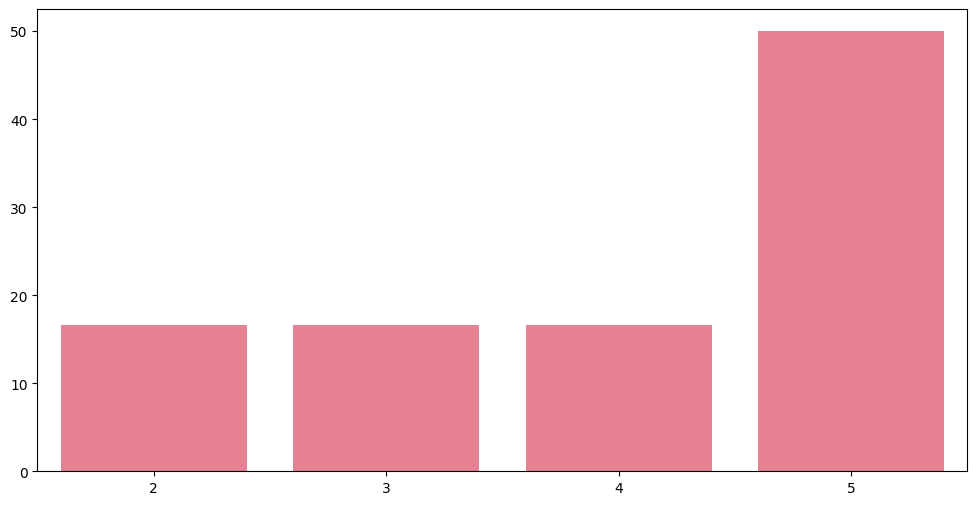


SATISFACTION INSIGHTS:
Overall Satisfaction Level: Good
⚠️ Significant dissatisfaction detected (>10% give 1-2 stars)


In [30]:
# Customer satisfaction analysis
satisfaction_metrics = business_report['customer_satisfaction']

if 'error' not in satisfaction_metrics:
    print(f"CUSTOMER SATISFACTION ANALYSIS - {ANALYSIS_YEAR}")
    print("=" * 50)
    print(f"Average Review Score: {satisfaction_metrics['avg_review_score']:.2f}/5.0")
    print(f"Total Reviews: {satisfaction_metrics['total_reviews']:,}")
    print(f"5-Star Reviews: {satisfaction_metrics['score_5_percentage']:.1f}%")
    print(f"4+ Star Reviews: {satisfaction_metrics['score_4_plus_percentage']:.1f}%")
    print(f"Low Satisfaction (1-2 stars): {satisfaction_metrics['score_1_2_percentage']:.1f}%")

    # Review distribution visualization
    review_fig = visualizer.plot_review_distribution(figsize=(12, 6))
    plt.show()

    # Satisfaction insights
    avg_score = satisfaction_metrics['avg_review_score']
    satisfaction_level = 'Excellent' if avg_score >= 4.5 else 'Good' if avg_score >= 4.0 else 'Fair' if avg_score >= 3.5 else 'Poor'

    print(f"\nSATISFACTION INSIGHTS:")
    print(f"Overall Satisfaction Level: {satisfaction_level}")
    if satisfaction_metrics['score_4_plus_percentage'] >= 80:
        print("✅ Strong customer satisfaction (80%+ give 4+ stars)")
    elif satisfaction_metrics['score_1_2_percentage'] > 10:
        print("⚠️ Significant dissatisfaction detected (>10% give 1-2 stars)")
else:
    print("Customer satisfaction data not available for analysis")

In [31]:
# Delivery performance analysis
delivery_metrics = business_report['delivery_performance']

if 'error' not in delivery_metrics:
    print(f"DELIVERY PERFORMANCE ANALYSIS - {ANALYSIS_YEAR}")
    print("=" * 50)
    print(f"Average Delivery Time: {delivery_metrics['avg_delivery_days']:.1f} days")
    print(f"Median Delivery Time: {delivery_metrics['median_delivery_days']:.1f} days")
    print(f"Fast Delivery (≤3 days): {delivery_metrics['fast_delivery_percentage']:.1f}%")
    print(f"Slow Delivery (>7 days): {delivery_metrics['slow_delivery_percentage']:.1f}%")

    # Delivery performance evaluation
    avg_delivery = delivery_metrics['avg_delivery_days']
    delivery_rating = 'Excellent' if avg_delivery <= 3 else 'Good' if avg_delivery <= 5 else 'Fair' if avg_delivery <= 7 else 'Poor'

    print(f"\nDELIVERY INSIGHTS:")
    print(f"Delivery Performance Rating: {delivery_rating}")

    if delivery_metrics['fast_delivery_percentage'] >= 30:
        print("✅ Strong fast delivery capability")
    if delivery_metrics['slow_delivery_percentage'] > 20:
        print("⚠️ High percentage of slow deliveries needs attention")

    # Delivery speed impact on satisfaction
    if 'error' not in satisfaction_metrics:
        print(f"\nDELIVERY-SATISFACTION CORRELATION:")
        # This would require more detailed analysis of the relationship
        print(f"Average satisfaction score: {satisfaction_metrics['avg_review_score']:.2f}")
        print(f"Fast delivery rate: {delivery_metrics['fast_delivery_percentage']:.1f}%")
else:
    print("Delivery performance data not available for analysis")

DELIVERY PERFORMANCE ANALYSIS - 2023
Average Delivery Time: 4.0 days
Median Delivery Time: 4.0 days
Fast Delivery (≤3 days): 0.0%
Slow Delivery (>7 days): 0.0%

DELIVERY INSIGHTS:
Delivery Performance Rating: Good

DELIVERY-SATISFACTION CORRELATION:
Average satisfaction score: 4.00
Fast delivery rate: 0.0%


## 6. Summary of Key Observations {#summary}

### Executive Summary

Based on the comprehensive analysis of the e-commerce data, here are the key findings and recommendations:

In [33]:
# Generate executive summary
print(f"EXECUTIVE SUMMARY - {ANALYSIS_YEAR} BUSINESS PERFORMANCE")
print("=" * 60)

# Key metrics summary
revenue_metrics = business_report['revenue_metrics']
print(f"\n📊 FINANCIAL PERFORMANCE:")
print(f"   • Total Revenue: ${revenue_metrics['total_revenue']:,.0f}")
print(f"   • Total Orders: {revenue_metrics['total_orders']:,}")
print(f"   • Average Order Value: ${revenue_metrics['average_order_value']:,.0f}")

if 'revenue_growth_rate' in revenue_metrics:
    growth_direction = "📈" if revenue_metrics['revenue_growth_rate'] > 0 else "📉"
    print(f"   • Revenue Growth: {growth_direction} {revenue_metrics['revenue_growth_rate']:+.1f}% vs {COMPARISON_YEAR}")

# Product insights
if 'error' not in business_report['product_performance']:
    top_category = business_report['product_performance']['top_categories'].iloc[0]
    print(f"\n🛍️ PRODUCT PERFORMANCE:")
    print(f"   • Top Category: {top_category['product_category_name']} (${top_category['total_revenue']:,.0f})")
    print(f"   • Category Market Share: {top_category['revenue_share']:.1f}%")

# Geographic insights
geo_data = business_report['geographic_performance']
if 'error' not in geo_data.columns:
    top_state = geo_data.iloc[0]
    print(f"\n🗺️ GEOGRAPHIC PERFORMANCE:")
    print(f"   • Top Market: {top_state['state']} (${top_state['revenue']:,.0f})")
    print(f"   • Active Markets: {len(geo_data)} states")

# Customer experience
if 'error' not in business_report['customer_satisfaction']:
    satisfaction = business_report['customer_satisfaction']
    print(f"\n⭐ CUSTOMER EXPERIENCE:")
    print(f"   • Average Rating: {satisfaction['avg_review_score']:.1f}/5.0")
    print(f"   • High Satisfaction: {satisfaction['score_4_plus_percentage']:.0f}% (4+ stars)")

if 'error' not in business_report['delivery_performance']:
    delivery = business_report['delivery_performance']
    print(f"   • Average Delivery: {delivery['avg_delivery_days']:.1f} days")
    print(f"   • Fast Delivery: {delivery['fast_delivery_percentage']:.0f}% (≤3 days)")

print(f"\n" + "=" * 60)

EXECUTIVE SUMMARY - 2023 BUSINESS PERFORMANCE

📊 FINANCIAL PERFORMANCE:
   • Total Revenue: $900
   • Total Orders: 5
   • Average Order Value: $180
   • Revenue Growth: 📈 +inf% vs 2022

🛍️ PRODUCT PERFORMANCE:
   • Top Category: electronics ($600)
   • Category Market Share: 66.7%

🗺️ GEOGRAPHIC PERFORMANCE:
   • Top Market: NY ($400)
   • Active Markets: 3 states

⭐ CUSTOMER EXPERIENCE:
   • Average Rating: 4.0/5.0
   • High Satisfaction: 67% (4+ stars)
   • Average Delivery: 4.0 days
   • Fast Delivery: 0% (≤3 days)



### Strategic Recommendations

Based on the analysis results, here are the key strategic recommendations:

In [34]:
# Generate recommendations based on analysis
print("STRATEGIC RECOMMENDATIONS")
print("=" * 40)

recommendations = []

# Revenue-based recommendations
if 'revenue_growth_rate' in revenue_metrics:
    if revenue_metrics['revenue_growth_rate'] < 0:
        recommendations.append("🔴 PRIORITY: Address negative revenue growth through customer acquisition and retention strategies")
    elif revenue_metrics['revenue_growth_rate'] < 5:
        recommendations.append("🟡 Focus on accelerating growth through market expansion and product diversification")
    else:
        recommendations.append("🟢 Maintain strong growth momentum while optimizing operational efficiency")

# Product recommendations
if 'error' not in business_report['product_performance']:
    top_5_share = business_report['product_performance']['top_categories'].head(5)['revenue_share'].sum()
    if top_5_share > 70:
        recommendations.append("📦 Consider diversifying product portfolio to reduce dependency on top categories")
    else:
        recommendations.append("📦 Leverage balanced product portfolio to explore cross-selling opportunities")

# Customer experience recommendations
if 'error' not in business_report['customer_satisfaction']:
    satisfaction = business_report['customer_satisfaction']
    if satisfaction['avg_review_score'] < 4.0:
        recommendations.append("⭐ PRIORITY: Improve customer satisfaction through quality and service enhancements")
    if satisfaction['score_1_2_percentage'] > 10:
        recommendations.append("⚠️ Address root causes of customer dissatisfaction to reduce negative reviews")

# Delivery recommendations
if 'error' not in business_report['delivery_performance']:
    delivery = business_report['delivery_performance']
    if delivery['avg_delivery_days'] > 7:
        recommendations.append("🚚 PRIORITY: Optimize logistics to reduce average delivery time")
    if delivery['fast_delivery_percentage'] < 20:
        recommendations.append("⚡ Invest in fast delivery capabilities to improve customer experience")

# Geographic recommendations
geo_data = business_report['geographic_performance']
if 'error' not in geo_data.columns:
    if len(geo_data) < 30:
        recommendations.append("🗺️ Explore expansion opportunities in underserved geographic markets")

# Display recommendations
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

if not recommendations:
    print("✅ Business performance appears strong across all analyzed metrics")

print("\n" + "=" * 40)
print(f"Analysis completed for {ANALYSIS_YEAR}")
if COMPARISON_YEAR:
    print(f"Comparison baseline: {COMPARISON_YEAR}")
print(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

STRATEGIC RECOMMENDATIONS
1. 🟢 Maintain strong growth momentum while optimizing operational efficiency
2. 📦 Consider diversifying product portfolio to reduce dependency on top categories
3. ⚠️ Address root causes of customer dissatisfaction to reduce negative reviews
4. ⚡ Invest in fast delivery capabilities to improve customer experience
5. 🗺️ Explore expansion opportunities in underserved geographic markets

Analysis completed for 2023
Comparison baseline: 2022
Generated on: 2026-03-04 03:35:17


---

## Analysis Configuration Summary

This notebook provides a comprehensive, configurable framework for e-commerce business analysis. Key features:

- **Configurable Time Periods**: Easily adjust analysis and comparison years
- **Modular Architecture**: Reusable data loading and metrics calculation modules
- **Comprehensive Metrics**: Revenue, product, geographic, and customer experience analysis
- **Visual Insights**: Interactive charts and geographic visualizations
- **Strategic Recommendations**: Data-driven business insights and action items

### Next Steps

1. **Regular Monitoring**: Schedule monthly/quarterly runs of this analysis
2. **Deeper Segmentation**: Analyze specific customer segments or product lines
3. **Predictive Analytics**: Implement forecasting models for future planning
4. **A/B Testing**: Design experiments to test strategic recommendations
5. **Real-time Dashboards**: Create live dashboards for ongoing monitoring

---

*This analysis framework is designed to be easily maintained and extended for future business intelligence needs.*